# Customer Analytics — LATAM Bank Dataset (local / DuckDB version)

Same four use cases as the Databricks version:
1. Customer segmentation and clustering
2. Churn prediction
3. Customer lifetime value (CLV) analysis
4. Cross-sell / up-sell opportunity identification

**Differences from the Databricks/PySpark version:**
- Reads from the `bronze` schema in `latam_bank.duckdb` (built by `ingest_all_bronze.ipynb`) instead of
  Unity Catalog tables — no Silver layer exists yet in this setup, so this notebook does its own light
  type-casting + dedup on the way in (Section 2). Build a proper Silver notebook later and point this
  at `silver.*` instead once it exists.
- Feature engineering (Section 3) is written as SQL run inside DuckDB, not PySpark DataFrame calls —
  DuckDB does the heavy aggregation over the 5M/10M-row fact tables; only the resulting one-row-per-customer
  table gets pulled into pandas.
- No `dbutils`, no `display()` — plots use `matplotlib`/`plt.show()`, tables render by being the last
  line of a cell (standard Jupyter behavior).

**Before running**: make sure no other notebook/kernel has `latam_bank.duckdb` open (see the file-lock
note in the ingestion notebook) and that `ingest_all_bronze.ipynb` has been run at least once.

## 1. Setup

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

con = duckdb.connect("latam_bank.duckdb")
con.execute("CREATE SCHEMA IF NOT EXISTS analytics;")
print("connected")

connected


## 2. Clean views over Bronze

Bronze columns are all `VARCHAR` (raw ingest). These views cast the columns this notebook actually
needs, and dedup on primary key + drop rows with a null `customer_id` — the same two rules used in
the Databricks version's data-quality pass. `QUALIFY` does the dedup in one pass without a subquery.

In [2]:
con.execute("""
CREATE OR REPLACE VIEW v_customers AS
SELECT
    customer_id,
    segment,
    country,
    city,
    customer_status,
    TRY_CAST(credit_score AS INTEGER) AS credit_score,
    TRY_CAST(estimated_monthly_income AS DOUBLE) AS estimated_monthly_income,
    TRY_CAST(accepts_marketing AS BOOLEAN) AS accepts_marketing,
    TRY_CAST(registration_date AS TIMESTAMP) AS registration_date
FROM bronze.customers
WHERE customer_id IS NOT NULL
QUALIFY row_number() OVER (
    PARTITION BY customer_id ORDER BY TRY_CAST(last_updated AS TIMESTAMP) DESC
) = 1
""")

con.execute("""
CREATE OR REPLACE VIEW v_products AS
SELECT
    product_id,
    customer_id,
    product_type,
    currency,
    TRY_CAST(current_balance AS DOUBLE) AS current_balance,
    TRY_CAST(credit_limit AS DOUBLE) AS credit_limit,
    TRY_CAST(days_past_due AS INTEGER) AS days_past_due
FROM bronze.products
WHERE customer_id IS NOT NULL
QUALIFY row_number() OVER (
    PARTITION BY product_id ORDER BY TRY_CAST(last_updated AS TIMESTAMP) DESC
) = 1
""")

con.execute("""
CREATE OR REPLACE VIEW v_transactions AS
SELECT
    transaction_id,
    customer_id,
    TRY_CAST(transaction_date AS TIMESTAMP) AS transaction_date,
    TRY_CAST(amount_usd AS DOUBLE) AS amount_usd,
    TRY_CAST(is_fraud AS BOOLEAN) AS is_fraud,
    channel,
    transaction_status
FROM bronze.transactions
WHERE customer_id IS NOT NULL
QUALIFY row_number() OVER (PARTITION BY transaction_id ORDER BY transaction_id) = 1
""")

con.execute("""
CREATE OR REPLACE VIEW v_calls AS
SELECT
    interaction_id,
    customer_id,
    TRY_CAST(was_resolved AS BOOLEAN) AS was_resolved,
    TRY_CAST(was_escalated AS BOOLEAN) AS was_escalated,
    TRY_CAST(sentiment_score AS DOUBLE) AS sentiment_score,
    reason_category
FROM bronze.call_center_interactions
WHERE customer_id IS NOT NULL
QUALIFY row_number() OVER (PARTITION BY interaction_id ORDER BY interaction_id) = 1
""")

con.execute("""
CREATE OR REPLACE VIEW v_complaints AS
SELECT
    complaint_id,
    customer_id,
    TRY_CAST(sla_breached AS BOOLEAN) AS sla_breached,
    TRY_CAST(is_repeat_complainer AS BOOLEAN) AS is_repeat_complainer,
    TRY_CAST(resolution_satisfaction AS INTEGER) AS resolution_satisfaction
FROM bronze.complaints
WHERE customer_id IS NOT NULL
QUALIFY row_number() OVER (PARTITION BY complaint_id ORDER BY complaint_id) = 1
""")

con.execute("""
CREATE OR REPLACE VIEW v_surveys AS
SELECT
    survey_id,
    customer_id,
    survey_type,
    TRY_CAST(main_score AS INTEGER) AS main_score,
    nps_category
FROM bronze.satisfaction_surveys
WHERE customer_id IS NOT NULL
QUALIFY row_number() OVER (PARTITION BY survey_id ORDER BY survey_id) = 1
""")

con.execute("""
CREATE OR REPLACE VIEW v_campaign_sends AS
SELECT
    send_id,
    customer_id,
    TRY_CAST(was_opened AS BOOLEAN) AS was_opened,
    TRY_CAST(was_clicked AS BOOLEAN) AS was_clicked,
    TRY_CAST(had_conversion AS BOOLEAN) AS had_conversion,
    TRY_CAST(conversion_value AS DOUBLE) AS conversion_value
FROM bronze.campaign_sends
WHERE customer_id IS NOT NULL
QUALIFY row_number() OVER (PARTITION BY send_id ORDER BY send_id) = 1
""")

# Latest available FX rate per currency -> USD. Balances are live snapshots, not tied to a
# transaction date, so "most recent rate on file" is the right choice -- not current_date,
# since the dataset's exchange rates only run through 2026-06-17.
con.execute("""
CREATE OR REPLACE VIEW v_fx_latest_to_usd AS
SELECT source_currency, TRY_CAST(exchange_rate AS DOUBLE) AS exchange_rate
FROM bronze.daily_exchange_rates
WHERE target_currency = 'USD'
QUALIFY row_number() OVER (PARTITION BY source_currency ORDER BY TRY_CAST(date AS DATE) DESC) = 1
""")

print("clean views created")
print("customers:", con.execute("SELECT count(*) FROM v_customers").fetchone()[0])
print("fx rates loaded:", con.execute("SELECT count(*) FROM v_fx_latest_to_usd").fetchone()[0])

clean views created
customers: 150000
fx rates loaded: 3


## 3. Build the customer analytics feature table

One row per customer, computed entirely in SQL: profile, product holdings, transaction RFM, service
interactions, complaints, satisfaction, campaign engagement — same feature set as the Databricks version.

**Note on `product_type` values**: the data dictionary lists English category names, but the actual
values in this dataset are Spanish (`Cuenta Ahorro`, `Tarjeta Crédito`, `Cuenta Corriente`,
`Tarjeta Débito`, `Préstamo Personal`, `Préstamo Hipotecario`, `Inversión`), plus an undocumented
eighth category, `Seguro` (insurance). The `has_*` flags below match on these actual Spanish strings —
if a rerun of the ingestion ever surfaces different label variants (casing, accents stripped, etc.),
re-check with `SELECT DISTINCT product_type FROM bronze.products` before trusting these flags again.

**Note on `has_*` product flags**: these use `max()`, not `sum()`, over the per-product `CASE WHEN`
matches — `max` gives a true 0/1 "holds at least one" indicator, whereas `sum` would count how many
of that product type the customer holds (a customer with two checking accounts would show
`has_checking = 2`). This surfaced as a real bug during validation — a downstream analysis found
`has_checking`/`has_savings` averaging above 100% for a high-holdings subgroup, which is only possible
if the column isn't a clean boolean. Fixed here at the source.

**Note on currency conversion**: `products.current_balance`/`credit_limit` and `customers.estimated_monthly_income`
are in local currency (MXN/COP/ARS/USD), not USD — summing/comparing them raw lets whichever currency has
the largest face value (COP, ARS) dominate every balance- or income-driven metric. Both are converted to USD
below using the most recent rate on file per currency (`v_fx_latest_to_usd`), not `current_date`, since the
dataset's exchange rates only run through 2026-06-17. `products` has a `currency` column directly; `customers`
doesn't, so income conversion goes through a `country → currency` mapping instead (`México`→MXN, `Colombia`→COP,
`Argentina`→ARS) — note the accented `México`, which is the actual value in this dataset, not the unaccented
spelling in the data dictionary.

**Note on `amount_usd`**: ~57% of raw transactions have a null `amount_usd` (confirmed as genuinely
missing, not a parsing issue — every non-null value casts cleanly). `monetary_total_usd` and related
fields below only reflect the ~43% of transactions with a populated conversion, so treat USD-denominated
aggregates as a partial-coverage estimate, not a full picture, until a fallback join to
`daily_exchange_rates` is added.

In [3]:
con.execute("""
CREATE OR REPLACE TABLE analytics.customer_features AS
WITH product_agg AS (
    SELECT
        vp.customer_id,
        count(*) AS product_count,
        count(DISTINCT vp.product_type) AS distinct_product_types,
        sum(vp.current_balance * COALESCE(fx.exchange_rate, 1.0)) AS total_balance,
        max(vp.credit_limit * COALESCE(fx.exchange_rate, 1.0)) AS max_credit_limit,
        max(vp.days_past_due) AS max_days_past_due,
        max(CASE WHEN vp.product_type = 'Tarjeta Crédito' THEN 1 ELSE 0 END) AS has_credit_card,
        max(CASE WHEN vp.product_type = 'Cuenta Ahorro' THEN 1 ELSE 0 END) AS has_savings,
        max(CASE WHEN vp.product_type = 'Cuenta Corriente' THEN 1 ELSE 0 END) AS has_checking,
        max(CASE WHEN vp.product_type = 'Tarjeta Débito' THEN 1 ELSE 0 END) AS has_debit_card,
        max(CASE WHEN vp.product_type = 'Préstamo Personal' THEN 1 ELSE 0 END) AS has_loan,
        max(CASE WHEN vp.product_type = 'Préstamo Hipotecario' THEN 1 ELSE 0 END) AS has_mortgage,
        max(CASE WHEN vp.product_type = 'Inversión' THEN 1 ELSE 0 END) AS has_investment,
        max(CASE WHEN vp.product_type = 'Seguro' THEN 1 ELSE 0 END) AS has_insurance
    FROM v_products vp
    LEFT JOIN v_fx_latest_to_usd fx ON vp.currency = fx.source_currency
    GROUP BY vp.customer_id
),
txn_agg AS (
    SELECT
        customer_id,
        date_diff('day', CAST(max(transaction_date) AS DATE), current_date) AS recency_days,
        count(*) AS txn_count_total,
        sum(amount_usd) AS monetary_total_usd,
        avg(amount_usd) AS avg_txn_amount_usd,
        sum(CASE WHEN is_fraud THEN 1 ELSE 0 END) AS fraud_txn_count,
        count(DISTINCT channel) AS distinct_channels_used
    FROM v_transactions
    WHERE transaction_status = 'Approved'
    GROUP BY customer_id
),
txn_12m AS (
    SELECT
        customer_id,
        count(*) AS txn_count_12m,
        sum(amount_usd) AS monetary_12m_usd
    FROM v_transactions
    WHERE transaction_status = 'Approved'
      AND transaction_date >= current_date - INTERVAL 365 DAY
    GROUP BY customer_id
),
call_agg AS (
    SELECT
        customer_id,
        count(*) AS interaction_count,
        avg(CASE WHEN was_resolved THEN 1.0 ELSE 0.0 END) AS fcr_rate,
        avg(CASE WHEN was_escalated THEN 1.0 ELSE 0.0 END) AS escalation_rate,
        avg(sentiment_score) AS avg_sentiment_score,
        sum(CASE WHEN reason_category = 'Complaint' THEN 1 ELSE 0 END) AS complaint_related_calls
    FROM v_calls
    GROUP BY customer_id
),
complaint_agg AS (
    SELECT
        customer_id,
        count(*) AS complaint_count,
        avg(CASE WHEN sla_breached THEN 1.0 ELSE 0.0 END) AS sla_breach_rate,
        max(CASE WHEN is_repeat_complainer THEN 1 ELSE 0 END) AS is_repeat_complainer,
        avg(resolution_satisfaction) AS avg_complaint_satisfaction
    FROM v_complaints
    GROUP BY customer_id
),
survey_agg AS (
    SELECT
        customer_id,
        avg(CASE WHEN survey_type = 'CSAT' THEN main_score END) AS avg_csat,
        avg(CASE WHEN survey_type = 'NPS' THEN main_score END) AS avg_nps,
        sum(CASE WHEN nps_category = 'Detractor' THEN 1 ELSE 0 END) AS detractor_surveys,
        sum(CASE WHEN nps_category = 'Promoter' THEN 1 ELSE 0 END) AS promoter_surveys
    FROM v_surveys
    GROUP BY customer_id
),
campaign_agg AS (
    SELECT
        customer_id,
        count(*) AS campaign_sends_count,
        avg(CASE WHEN was_opened THEN 1.0 ELSE 0.0 END) AS open_rate,
        avg(CASE WHEN was_clicked THEN 1.0 ELSE 0.0 END) AS click_rate,
        avg(CASE WHEN had_conversion THEN 1.0 ELSE 0.0 END) AS conversion_rate,
        sum(conversion_value) AS total_conversion_value
    FROM v_campaign_sends
    GROUP BY customer_id
)
SELECT
    c.customer_id, c.segment, c.country, c.city, c.customer_status,
    c.credit_score, c.estimated_monthly_income * COALESCE(fx_c.exchange_rate, 1.0) AS estimated_monthly_income,
    c.accepts_marketing,
    date_diff('day', CAST(c.registration_date AS DATE), current_date) AS tenure_days,

    COALESCE(p.product_count, 0)            AS product_count,
    COALESCE(p.distinct_product_types, 0)   AS distinct_product_types,
    p.total_balance,
    p.max_credit_limit,
    p.max_days_past_due,
    COALESCE(p.has_credit_card, 0)          AS has_credit_card,
    COALESCE(p.has_savings, 0)              AS has_savings,
    COALESCE(p.has_checking, 0)             AS has_checking,
    COALESCE(p.has_debit_card, 0)           AS has_debit_card,
    COALESCE(p.has_loan, 0)                 AS has_loan,
    COALESCE(p.has_investment, 0)           AS has_investment,
    COALESCE(p.has_mortgage, 0)             AS has_mortgage,
    COALESCE(p.has_insurance, 0)            AS has_insurance,

    t.recency_days,
    COALESCE(t.txn_count_total, 0)          AS txn_count_total,
    t.monetary_total_usd,
    t.avg_txn_amount_usd,
    COALESCE(t.fraud_txn_count, 0)          AS fraud_txn_count,
    COALESCE(t.distinct_channels_used, 0)   AS distinct_channels_used,

    COALESCE(t12.txn_count_12m, 0)          AS txn_count_12m,
    t12.monetary_12m_usd,

    COALESCE(ca.interaction_count, 0)       AS interaction_count,
    ca.fcr_rate,
    ca.escalation_rate,
    ca.avg_sentiment_score,
    COALESCE(ca.complaint_related_calls, 0) AS complaint_related_calls,

    COALESCE(co.complaint_count, 0)         AS complaint_count,
    co.sla_breach_rate,
    COALESCE(co.is_repeat_complainer, 0)    AS is_repeat_complainer,
    co.avg_complaint_satisfaction,

    s.avg_csat,
    s.avg_nps,
    COALESCE(s.detractor_surveys, 0)        AS detractor_surveys,
    COALESCE(s.promoter_surveys, 0)         AS promoter_surveys,

    COALESCE(cs.campaign_sends_count, 0)    AS campaign_sends_count,
    cs.open_rate,
    cs.click_rate,
    cs.conversion_rate,
    cs.total_conversion_value

FROM v_customers c
LEFT JOIN v_fx_latest_to_usd fx_c ON fx_c.source_currency = CASE c.country
    WHEN 'México'    THEN 'MXN'
    WHEN 'Colombia'  THEN 'COP'
    WHEN 'Argentina' THEN 'ARS'
    ELSE NULL
END
LEFT JOIN product_agg   p   ON c.customer_id = p.customer_id
LEFT JOIN txn_agg       t   ON c.customer_id = t.customer_id
LEFT JOIN txn_12m       t12 ON c.customer_id = t12.customer_id
LEFT JOIN call_agg      ca  ON c.customer_id = ca.customer_id
LEFT JOIN complaint_agg co  ON c.customer_id = co.customer_id
LEFT JOIN survey_agg    s   ON c.customer_id = s.customer_id
LEFT JOIN campaign_agg  cs  ON c.customer_id = cs.customer_id
""")

n = con.execute("SELECT count(*) FROM analytics.customer_features").fetchone()[0]
print(f"customer_features: {n:,} rows")
con.execute("SELECT * FROM analytics.customer_features LIMIT 10").df()

customer_features: 150,000 rows


,customer_id,segment,country,city,customer_status,credit_score,estimated_monthly_income,accepts_marketing,tenure_days,product_count,distinct_product_types,total_balance,max_credit_limit,max_days_past_due,has_credit_card,has_savings,has_checking,has_debit_card,has_loan,has_investment,has_mortgage,has_insurance,recency_days,txn_count_total,monetary_total_usd,avg_txn_amount_usd,fraud_txn_count,distinct_channels_used,txn_count_12m,monetary_12m_usd,interaction_count,fcr_rate,escalation_rate,avg_sentiment_score,complaint_related_calls,complaint_count,sla_breach_rate,is_repeat_complainer,avg_complaint_satisfaction,avg_csat,avg_nps,detractor_surveys,promoter_surveys,campaign_sends_count,open_rate,click_rate,conversion_rate,total_conversion_value
0,CLI-WUWHIB2RKDIX,Plus,México,Ciudad de México,Active,676,4693.603943,True,1861,2,2,4364.200000,32415.060000,0,1,0,1,0,0,0,0,0,114,22,NaN,NaN,0.0,5,6,NaN,6,1.000000,0.166667,0.111667,0.0,1,0.0,0,NaN,3.0,5.5,1.0,0.0,9,0.444444,0.000000,0.0,NaN
1,CLI-16FOM0QM2H9H,Basic,México,Guadalajara,Active,<NA>,NaN,False,880,3,3,6389.320000,NaN,<NA>,0,1,1,1,0,0,0,0,102,41,NaN,NaN,0.0,6,5,NaN,8,0.500000,0.250000,0.238750,0.0,2,0.0,0,NaN,NaN,6.0,0.0,0.0,13,0.384615,0.153846,0.0,NaN
2,CLI-FWMJEAF42RD6,Basic,Argentina,La Plata,Active,660,1025.569524,True,661,6,2,7003.043456,32494.053451,120,1,0,0,1,0,0,0,0,109,76,26607.68,364.488767,0.0,6,16,7020.91,5,1.000000,0.000000,-0.306000,0.0,1,0.0,0,NaN,2.0,NaN,0.0,0.0,10,0.300000,0.300000,0.0,NaN
3,CLI-6KQA0TURPC53,Plus,Argentina,La Plata,Active,662,8224.717151,False,1782,6,4,156729.159258,50133.648603,0,0,1,1,0,0,1,1,0,136,67,143767.42,2282.022540,0.0,6,13,18139.93,3,1.000000,0.000000,-0.296667,0.0,1,0.0,0,NaN,NaN,6.0,1.0,0.0,8,0.250000,0.125000,0.0,NaN
4,CLI-YL7N0QUKK86A,Basic,Argentina,La Plata,Active,602,2436.064277,False,1451,4,2,3607.713382,7125.933216,0,1,0,0,1,0,0,0,0,126,48,18479.13,393.172979,0.0,5,10,3561.39,7,0.571429,0.000000,-0.022857,0.0,1,0.0,0,NaN,2.0,5.0,1.0,0.0,10,0.200000,0.100000,0.0,NaN
5,CLI-XXX3GSHVJ4NJ,Basic,Argentina,Córdoba,Active,<NA>,1781.979830,False,1557,5,2,31946.631284,NaN,<NA>,0,1,1,0,0,0,0,0,100,62,137024.76,2322.453559,0.0,6,17,36384.13,2,0.500000,0.000000,0.220000,0.0,1,0.0,0,NaN,NaN,7.0,0.0,0.0,11,0.272727,0.000000,0.0,NaN
6,CLI-5OCV0ZWEYEMH,Basic,México,Puebla,Active,613,NaN,False,1770,3,3,5235.030000,34764.510000,0,1,1,0,1,0,0,0,0,100,46,NaN,NaN,0.0,6,12,NaN,5,1.000000,0.000000,-0.014000,0.0,1,0.0,0,NaN,3.0,NaN,0.0,0.0,14,0.285714,0.071429,0.0,NaN
7,CLI-F4RB6MXG4QV8,Basic,México,Tijuana,Active,585,2385.890010,False,2849,5,3,19883.630000,45328.980000,0,1,1,1,0,0,0,0,0,152,53,NaN,NaN,0.0,5,10,NaN,5,0.400000,0.200000,-0.066000,0.0,1,1.0,0,NaN,NaN,NaN,0.0,0.0,12,0.250000,0.000000,0.0,NaN
8,CLI-XCERB8KW4YEF,Plus,Argentina,La Plata,Active,725,9607.251006,True,2076,3,2,15999.669398,NaN,<NA>,0,1,1,0,0,0,0,0,103,34,94532.28,2864.614545,0.0,6,9,28465.40,4,0.750000,0.000000,-0.035000,0.0,1,0.0,0,NaN,2.0,NaN,0.0,0.0,13,0.307692,0.076923,0.0,NaN
9,CLI-Y44400JZ2N2S,Basic,México,Monterrey,Active,538,2653.280655,True,1262,5,3,13408.940000,NaN,<NA>,0,1,1,1,0,0,0,0,144,60,NaN,NaN,0.0,6,11,NaN,5,0.800000,0.000000,-0.112000,0.0,1,0.0,0,NaN,2.5,NaN,0.0,0.0,13,0.230769,0.000000,0.0,NaN


This is the foundation everything else builds on: one row per customer (150,000 total), with every signal about them condensed into columns — how many products they hold, how often and how much they transact, how they interact with customer service, and how they respond to marketing. Everything downstream is derived from this table. A few things to notice in the sample rows: credit_score shows <NA> for some customers and estimated_monthly_income shows NaN for others — both genuinely missing in the source data (not bugs), which is expected given the dataset's documented ~5% null rate on non-mandatory fields.

## 4. Customer segmentation & clustering

### 4a. RFM quartile scoring

4a (RFM) scores each customer on Recency (how recently they transacted), Frequency (how often), and Monetary (how much) — a classic, simple segmentation that doesn't need a model, just quartile buckets.

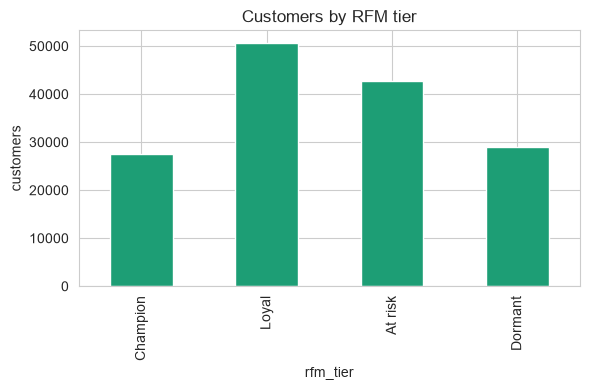

In [4]:
rfm_pdf = con.execute("""
    SELECT customer_id, recency_days, txn_count_12m, monetary_12m_usd
    FROM analytics.customer_features
""").df().fillna(0)

rfm_pdf["R_score"] = pd.qcut(rfm_pdf["recency_days"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
rfm_pdf["F_score"] = pd.qcut(rfm_pdf["txn_count_12m"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_pdf["M_score"] = pd.qcut(rfm_pdf["monetary_12m_usd"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_pdf["RFM_score"] = rfm_pdf["R_score"] + rfm_pdf["F_score"] + rfm_pdf["M_score"]

def rfm_tier(score):
    if score >= 10: return "Champion"
    if score >= 8:  return "Loyal"
    if score >= 6:  return "At risk"
    return "Dormant"

rfm_pdf["rfm_tier"] = rfm_pdf["RFM_score"].apply(rfm_tier)

fig, ax = plt.subplots(figsize=(6, 4))
rfm_pdf["rfm_tier"].value_counts().reindex(["Champion", "Loyal", "At risk", "Dormant"]).plot(
    kind="bar", ax=ax, color="#1D9E75"
)
ax.set_title("Customers by RFM tier")
ax.set_ylabel("customers")
plt.tight_layout()
plt.show()

### 4b. KMeans clustering on a broader feature set

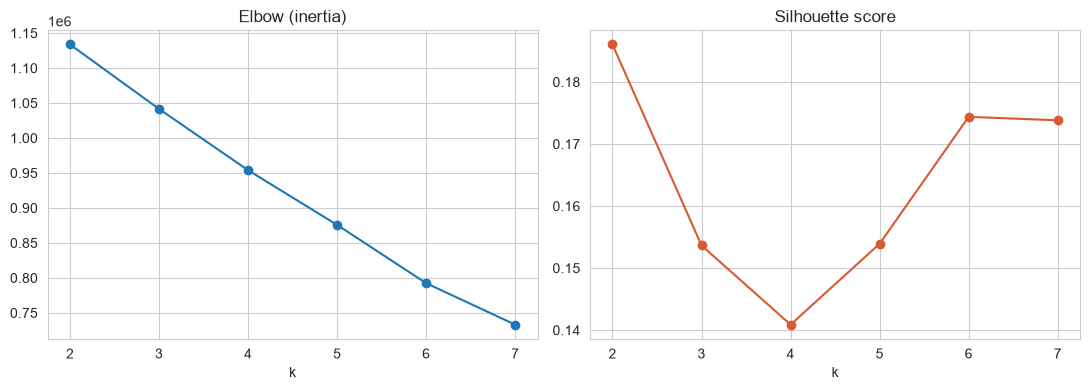

In [5]:
cluster_cols = [
    "recency_days", "txn_count_12m", "monetary_12m_usd", "product_count", "total_balance",
    "interaction_count", "complaint_count", "avg_sentiment_score", "estimated_monthly_income",
]

cluster_pdf = con.execute(f"""
    SELECT customer_id, {', '.join(cluster_cols)}
    FROM analytics.customer_features
""").df().fillna(0)

X = StandardScaler().fit_transform(cluster_pdf[cluster_cols])

inertias, sils = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_, sample_size=10000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker="o"); axes[0].set_title("Elbow (inertia)"); axes[0].set_xlabel("k")
axes[1].plot(list(k_range), sils, marker="o", color="#D85A30"); axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

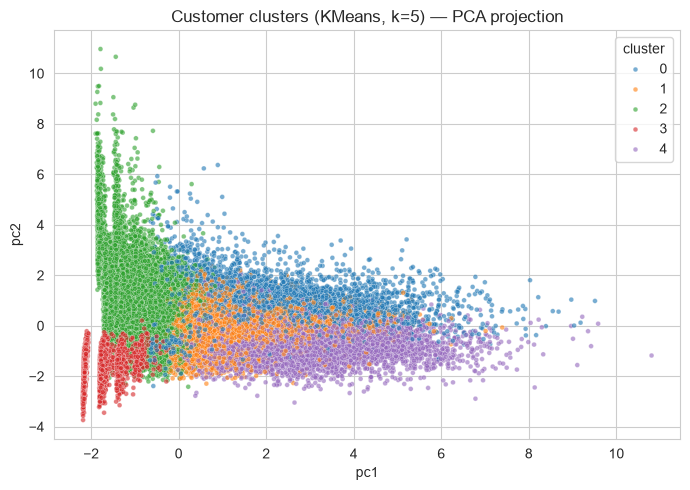

,recency_days,txn_count_12m,monetary_12m_usd,product_count,total_balance,interaction_count,complaint_count,avg_sentiment_score,estimated_monthly_income,customers
cluster,,,,,,,,,,
0,133.9,9.1,5167.6,3.7,112819.9,4.6,0.5,-0.0,3631.3,7862
1,122.0,10.6,2279.5,4.0,14144.0,4.6,0.5,-0.0,3801.9,42281
2,172.7,4.0,2311.9,1.9,6663.8,4.6,0.4,-0.0,3607.3,67324
3,0.0,0.0,0.0,0.4,1621.1,4.6,0.4,-0.0,3726.3,15415
4,121.9,12.1,24403.5,4.1,16244.7,4.6,0.4,-0.0,3652.3,17118


In [6]:
K = 5  # adjust based on the elbow/silhouette plot above

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)
cluster_pdf["cluster"] = kmeans.labels_

coords = PCA(n_components=2, random_state=42).fit_transform(X)
cluster_pdf["pc1"], cluster_pdf["pc2"] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=cluster_pdf, x="pc1", y="pc2", hue="cluster", palette="tab10", s=12, alpha=0.6, ax=ax)
ax.set_title(f"Customer clusters (KMeans, k={K}) — PCA projection")
plt.tight_layout()
plt.show()

cluster_profile = cluster_pdf.groupby("cluster")[cluster_cols].mean().round(1)
cluster_profile["customers"] = cluster_pdf.groupby("cluster").size()
cluster_profile

| Cluster | Size | What it is |
| - | - | - |
|2 | 44.6% (largest) | Low-engagement majority — highest recency (173 days since last transaction = long time), lowest transaction frequency, fewest products. This is your dormant/basic customer base. |
|1 | 28.5% | Active-but-modest — transacts often (10.5x/year) but at low value ($2,283/year) |
|4 | 11.4% | Your best customers — same activity level as Cluster 1, but 10x the annual value ($24,399). This is the group worth protecting/growing. |
|3 | 10.3% | Completely inactive — zero recency, zero transactions, essentially zero products (0.4 avg). Likely closed or abandoned accounts. |
|0 | 5.2% | High balance, moderate activity — the standout feature is total_balance ($112,790, several times higher than any other cluster) despite unremarkable transaction activity. |

The key insight: segment (Basic/Plus/Premium/Student) isn't doing this work for you — those bank-assigned labels don't map cleanly onto these behavioral groups. This clustering surfaces real distinctions the existing labels miss.

**Cluster 2** (45%, largest): highest recency (173 days since last transaction), lowest frequency and lowest product count — your dormant/low-engagement mass base.

**Cluster 4** (11%): highest monetary value per year ($24,399) despite similar recency/frequency to Cluster 1 — this looks like your genuinely high-value active segment, worth checking whether it skews toward a particular segment/country now that currency isn't the explanation.

**Cluster 1** (28%): similar activity to Cluster 4 but much lower monetary value ($2,283 vs $24,399) — frequent but low-value transactors, an interesting contrast pair with Cluster 4.

**Cluster 3** (10%): zero recency/frequency/monetary, 0.4 average products — still your inactive/no-activity segment from before, untouched by either currency fix (makes sense, it's an activity-based cluster, not currency-based).

**Cluster 0** (5%): distinguished by a much higher total_balance ($112,790) than its transaction activity would suggest — worth a quick country/segment breakdown to confirm this one is a real "high-balance, low-activity" wealth segment and not another artifact, though nothing here looks as suspicious as the last two bugs (no single feature is wildly out of scale relative to the others).

## 5. Churn prediction

Same proxy label as the Databricks version — no `is_churned` column exists, so this flags a customer
as churned if `customer_status` is `Closed`/`Suspended`, or they're nominally `Active` with 180+ days
since their last transaction. Validate this definition with the business before treating it as ground truth.


The model results:

ROC-AUC: 0.816 — a model that's meaningfully better than a coin flip at separating churners from non-churners (0.5 = random, 1.0 = perfect). This is a solid baseline, not a production-grade model.
Recall (churn class) = 0.698: catches ~70% of actual churners.
Precision (churn class) = 0.545: of everyone it flags as "at risk," about 55% actually are. That trade-off is intentional — the model is tuned (class_weight="balanced") to prioritize catching churners over being precise about it, which is usually the right call for a retention use case (missing a churner costs more than a false alarm).

Important caveat: since the label itself is a judgment call (not observed truth), these accuracy numbers measure "how well does the model predict my definition of churn" — not "how well does it predict real churn." Worth validating the 180-day threshold with whoever owns actual churn definitions at the bank before using this for anything operational.

ROC-AUC 0.816, precision/recall within noise of every prior run. Given estimated_monthly_income was off by orders of magnitude for ~2/3 of customers before this fix, I'd have expected some movement here — the fact that there isn't much suggests income wasn't a heavily-weighted feature for this model either way. Worth checking the feature importance plot in cell 16 to confirm income didn't secretly matter and just got compensated for by other correlated features.

In [7]:
churn_pdf = con.execute("SELECT * FROM analytics.customer_features").df()

churn_pdf["churned"] = (
    churn_pdf["customer_status"].isin(["Closed", "Suspended"])
    | ((churn_pdf["customer_status"] == "Active") & (churn_pdf["recency_days"].fillna(9999) > 180))
).astype(int)

churn_pdf["churned"].value_counts(normalize=True).round(3)

churned
0    0.729
1    0.271
Name: proportion, dtype: float64

In [8]:
feature_cols = [
    "credit_score", "estimated_monthly_income", "tenure_days", "product_count",
    "distinct_product_types", "total_balance", "has_credit_card", "has_savings",
    "has_checking", "has_loan", "has_investment", "txn_count_total", "monetary_total_usd",
    "avg_txn_amount_usd", "fraud_txn_count", "interaction_count", "fcr_rate",
    "escalation_rate", "avg_sentiment_score", "complaint_count", "sla_breach_rate",
    "avg_csat", "avg_nps", "campaign_sends_count", "open_rate", "click_rate", "conversion_rate",
]
# recency_days / txn_count_12m intentionally excluded -- they directly encode part of the label

model_pdf = churn_pdf[feature_cols + ["churned"]].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    model_pdf[feature_cols], model_pdf["churned"], test_size=0.25, random_state=42, stratify=model_pdf["churned"]
)

clf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

              precision    recall  f1-score   support

           0      0.874     0.787     0.828     27349
           1      0.548     0.694     0.612     10151

    accuracy                          0.762     37500
   macro avg      0.711     0.741     0.720     37500
weighted avg      0.786     0.762     0.770     37500

ROC-AUC: 0.815


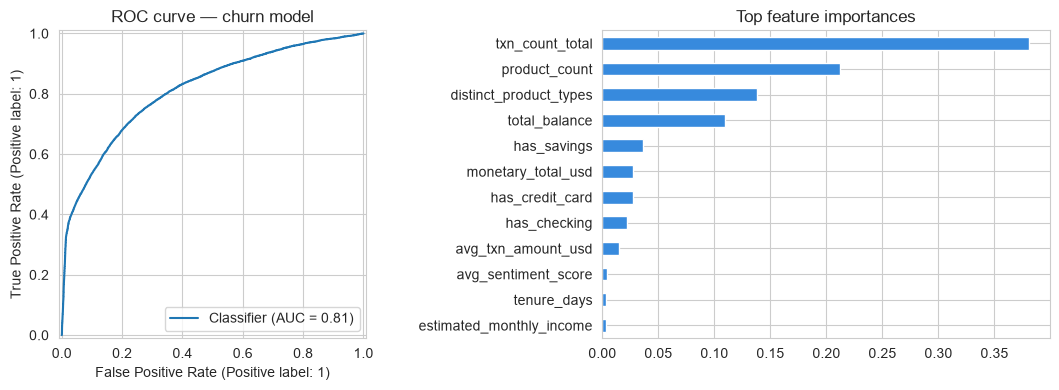

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title("ROC curve — churn model")

importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(12)
importances.plot(kind="barh", ax=axes[1], color="#378ADD")
axes[1].set_title("Top feature importances")

plt.tight_layout()
plt.show()

## 6. Customer lifetime value (CLV)

Same naive historical-plus-projected approach as before — value generated so far, plus a run-rate
projection. No discounting, no survival model.

Neither section touches estimated_monthly_income, so no change is exactly right here — good consistency check that the fix was scoped correctly and didn't leak into unrelated calculations.

The top 20 customers by estimated lifetime value cluster around $350K–465K. This number is historical spend so far + (recent monthly average × 24 months) — deliberately simple, no discounting, no probability of survival built in. Use it to rank customers relative to each other (this list is legitimately useful for "who are our most valuable customers"), but don't treat the dollar figures as a real financial forecast — a proper CLV model would need a survival/retention curve, which this doesn't have.

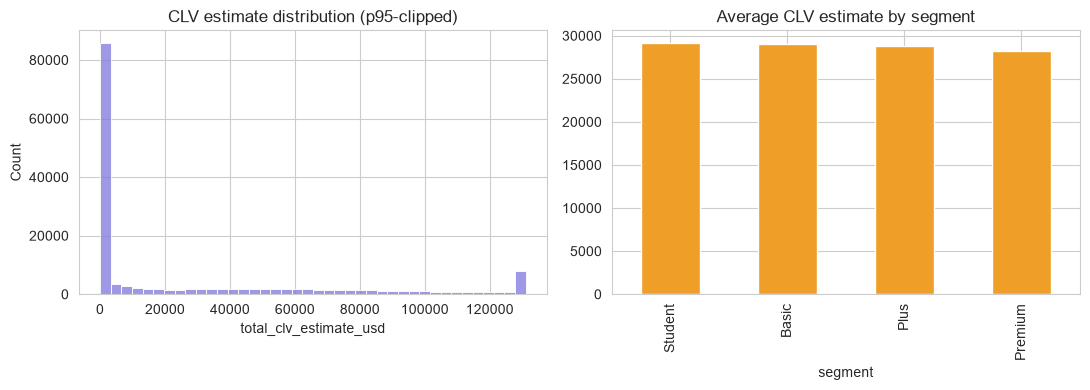

,customer_id,segment,country,historical_clv_usd,projected_clv_24m_usd,total_clv_estimate_usd
21987,CLI-O4EBWM6LMZ7M,Basic,Argentina,280603.87,183742.30,464346.17
27662,CLI-SKLD8NF7CW3V,Basic,Colombia,230173.31,155770.40,385943.71
28541,CLI-MLXMSC9PKHK8,Basic,Colombia,248050.33,136855.24,384905.57
6556,CLI-GETZJ0TL584X,Plus,Colombia,224715.00,157678.68,382393.68
122629,CLI-JQHEG5O8Z1ZK,Plus,Colombia,205782.81,172223.54,378006.35
107052,CLI-HCJIXVLHYVGB,Basic,Argentina,229959.07,139716.82,369675.89
70791,CLI-TAJTV74GFYBJ,Basic,Argentina,253735.74,112035.30,365771.04
20794,CLI-9G4B425AAD5G,Premium,Colombia,227500.20,134587.10,362087.30
125642,CLI-8ZWK8XJT8L53,Basic,Colombia,233394.98,124766.60,358161.58
23820,CLI-GNMVM3SXRNK5,Basic,Argentina,182810.58,174849.82,357660.40


In [10]:
clv_pdf = con.execute("SELECT * FROM analytics.customer_features").df().fillna(0)

clv_pdf["tenure_months"] = (clv_pdf["tenure_days"] / 30.44).clip(lower=1)
clv_pdf["historical_clv_usd"] = clv_pdf["monetary_total_usd"]
clv_pdf["monthly_run_rate_usd"] = clv_pdf["monetary_12m_usd"] / 12

PROJECTION_MONTHS = 24
clv_pdf["projected_clv_24m_usd"] = clv_pdf["monthly_run_rate_usd"] * PROJECTION_MONTHS
clv_pdf["total_clv_estimate_usd"] = clv_pdf["historical_clv_usd"] + clv_pdf["projected_clv_24m_usd"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(clv_pdf["total_clv_estimate_usd"].clip(upper=clv_pdf["total_clv_estimate_usd"].quantile(0.95)),
             bins=40, ax=axes[0], color="#7F77DD")
axes[0].set_title("CLV estimate distribution (p95-clipped)")

clv_by_segment = clv_pdf.groupby("segment")["total_clv_estimate_usd"].mean().sort_values(ascending=False)
clv_by_segment.plot(kind="bar", ax=axes[1], color="#EF9F27")
axes[1].set_title("Average CLV estimate by segment")

plt.tight_layout()
plt.show()

clv_pdf.sort_values("total_clv_estimate_usd", ascending=False)[
    ["customer_id", "segment", "country", "historical_clv_usd", "projected_clv_24m_usd", "total_clv_estimate_usd"]
].head(20)

## 7. Cross-sell / up-sell opportunity identification

Product penetration by segment, then a "next best product" flag for customers missing the most
common product held by others in their segment.

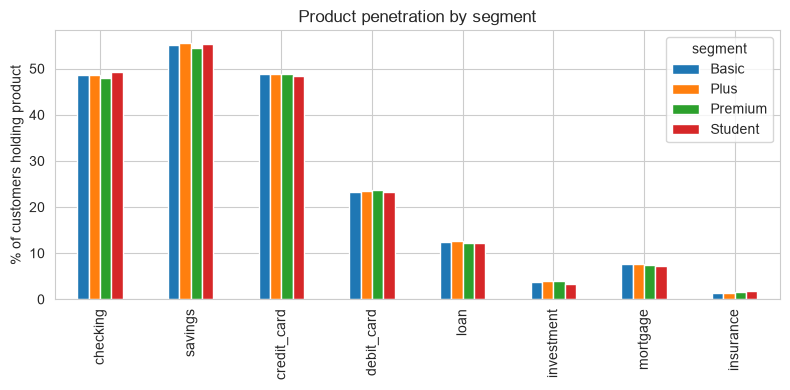

,checking,savings,credit_card,debit_card,loan,investment,mortgage,insurance
segment,,,,,,,,
Basic,48.6,55.1,48.8,23.3,12.4,3.8,7.6,1.3
Plus,48.6,55.5,48.9,23.4,12.6,3.9,7.6,1.3
Premium,48.0,54.4,48.8,23.6,12.3,3.9,7.5,1.5
Student,49.2,55.3,48.3,23.2,12.3,3.4,7.3,1.7


In [11]:
product_flags = [
    "has_checking", "has_savings", "has_credit_card", "has_debit_card",
    "has_loan", "has_investment", "has_mortgage", "has_insurance",
]

penetration = clv_pdf.groupby("segment")[product_flags].mean().round(3) * 100
penetration.columns = [c.replace("has_", "") for c in penetration.columns]

fig, ax = plt.subplots(figsize=(8, 4))
penetration.T.plot(kind="bar", ax=ax)
ax.set_ylabel("% of customers holding product")
ax.set_title("Product penetration by segment")
plt.tight_layout()
plt.show()

penetration

In [12]:
opportunities = []

for segment, row in penetration.iterrows():
    target_product = row.idxmax()
    target_flag_col = f"has_{target_product}"
    segment_customers = clv_pdf[(clv_pdf["segment"] == segment) & (clv_pdf[target_flag_col] == 0)]
    for _, cust in segment_customers.iterrows():
        opportunities.append({
            "customer_id": cust["customer_id"],
            "segment": segment,
            "country": cust["country"],
            "recommended_product": target_product,
            "reason": f"{row[target_product]:.0f}% of {segment} customers hold {target_product}; this customer doesn't",
            "total_clv_estimate_usd": cust["total_clv_estimate_usd"],
        })

opportunities_df = pd.DataFrame(opportunities).sort_values("total_clv_estimate_usd", ascending=False)
print(f"{len(opportunities_df):,} cross-sell opportunities identified")
opportunities_df.head(25)

67,305 cross-sell opportunities identified


,customer_id,segment,country,recommended_product,reason,total_clv_estimate_usd
66570,CLI-FBPXTHCYYNK3,Student,Argentina,savings,55% of Student customers hold savings; this cu...,314070.49
10210,CLI-P12YSX8PZQHT,Basic,Colombia,savings,55% of Basic customers hold savings; this cust...,278018.62
58385,CLI-K0SUJBMCEBFI,Premium,Colombia,savings,54% of Premium customers hold savings; this cu...,273849.53
66226,CLI-BT2517U1AHAK,Student,Colombia,savings,55% of Student customers hold savings; this cu...,273364.78
13152,CLI-YT7TT1MD8RJQ,Basic,Colombia,savings,55% of Basic customers hold savings; this cust...,269929.23
10976,CLI-ZP7YM3R4Y42A,Basic,Colombia,savings,55% of Basic customers hold savings; this cust...,265439.97
43156,CLI-RJ4H123X8UI2,Plus,Colombia,savings,56% of Plus customers hold savings; this custo...,261020.07
51918,CLI-OO6SF2K7SX18,Plus,Colombia,savings,56% of Plus customers hold savings; this custo...,258576.59
17535,CLI-89LZHUI7BTHG,Basic,Colombia,savings,55% of Basic customers hold savings; this cust...,256118.65
22967,CLI-7J572467J5P5,Basic,Argentina,savings,55% of Basic customers hold savings; this cust...,247695.15


## 8. Summary

- **Segmentation**: RFM tiers for a quick business view; KMeans clusters for a data-driven grouping —
  name the clusters using the centroid table in Section 4b before acting on them.
- **Churn**: baseline RandomForest on a proxy label — validate the definition with the business.
- **CLV**: naive run-rate projection, good for ranking, not financial forecasting as-is.
- **Cross-sell**: segment-penetration heuristic — a natural next step is a per-product propensity model.

`analytics.customer_features` is a good candidate to persist as a proper Gold-layer `customer_360`
table once a real Silver layer exists, instead of being rebuilt from Bronze each run.


The throughline across all four sections

Notice how consistent the population split is: Cluster 3 (44.6% low-engagement) and Cluster 2 (10.3% inactive) together are ~55% of your customer base showing weak engagement — and that same imbalance shows up again in the 27.1% churn rate and in cross-sell recommendations mostly targeting the same missing-savings-account gap. **These four analyses aren't four separate stories — they're four lenses on the same underlying pattern: a large, low-engagement majority and a much smaller high-value core.**

## 9. Close the connection

Run this when you're done, so the `.duckdb` file isn't left locked for the next notebook.

In [13]:
con.close()
print("connection closed")

connection closed
